In [2]:
import pandas as pd

# Load the fixed-width file
df = pd.read_fwf(r"C:\Users\salma\OneDrive\Desktop\New folder\blitz_rating_list\blitz_rating_list.txt", skipfooter=0)

# Display the result
print(df)

        ID Number                   Name  Fed Sex  Tit WTit OTit  FOA  FEB26  \
0        40129322                9147028  NED   M  NaN  NaN  NaN  NaN   1530   
1       537001345   A Arbhin Vanniarajan  IND   M  NaN  NaN  NaN  NaN   1472   
2        10245154  A B M Jobair, Hossain  BAN   M  NaN  NaN  NaN  NaN   1748   
3       537070436              A Darshil  IND   M  NaN  NaN  NaN  NaN   1459   
4        10207538       A E M, Doshtagir  BAN   M  NaN  NaN  NaN  NaN   1916   
...           ...                    ...  ...  ..  ...  ...  ...  ...    ...   
289330   55755011        Zyuzina, Marina  RUS   F  NaN  NaN  NaN  NaN   1557   
289331   21054274        Zywczak, Damian  POL   M  NaN  NaN  NaN  NaN   1632   
289332    1189980         Zywert, Kacper  POL   M  NaN  NaN  NaN  NaN   1765   
289333   41818385       Zyzanski, Michal  POL   M  NaN  NaN  NaN  NaN   1421   
289334  545028842        Zyznowski, Adam  POL   M  NaN  NaN  NaN  NaN   1483   

        Gms   K  B-day Flag  
0        

In [3]:
len(df)

289335

In [4]:
import matplotlib.pyplot as plt

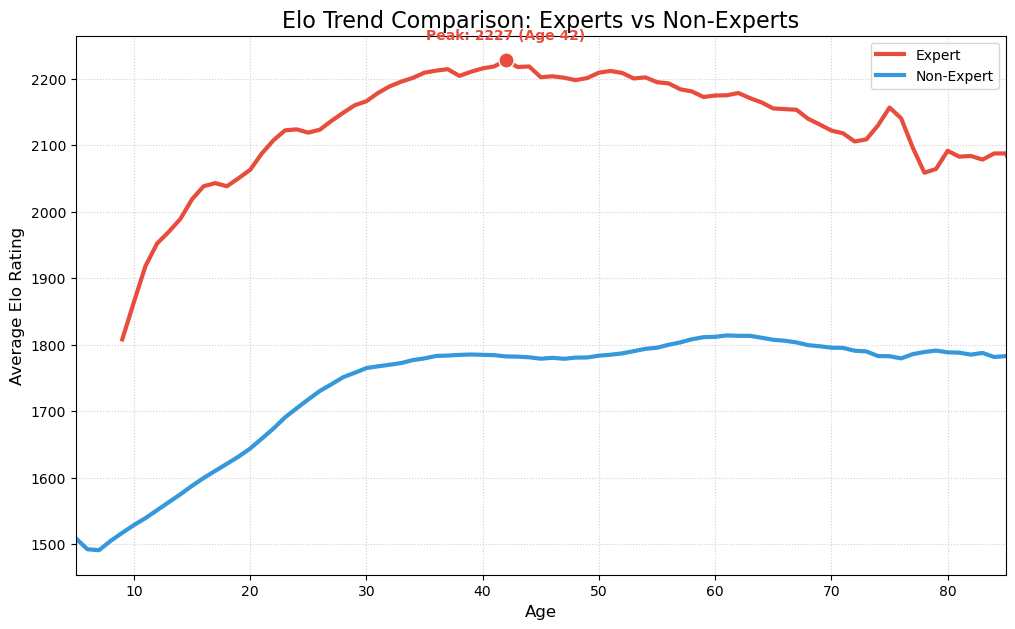

In [6]:
# 1. Clean Data & Calculate Age
df['Age'] = 2026 - df['B-day']

# 2. Define Categories
# 'Expert' if they have any title (GM, IM, etc.), otherwise 'Non-Expert'
df['Category'] = df['Tit'].apply(lambda x: 'Expert' if pd.notnull(x) and x != '' else 'Non-Expert')

# 3. Group by Category and Age for the average Elo
trend = df.groupby(['Category', 'Age'])['FEB26'].mean().reset_index()

# 4. Create the Plot
plt.figure(figsize=(12, 7))
colors = {'Expert': '#e74c3c', 'Non-Expert': '#3498db'}

for cat in ['Expert', 'Non-Expert']:
    # Get data for this category
    subset = trend[trend['Category'] == cat].sort_values('Age')
    
    # Optional: Smooth the line for better visibility
    subset['Smoothed'] = subset['FEB26'].rolling(window=3, center=True).mean().fillna(subset['FEB26'])
    
    plt.plot(subset['Age'], subset['Smoothed'], label=cat, color=colors[cat], linewidth=3)
    
    # 5. Find and Mark the Peak
    peak_idx = subset['Smoothed'].idxmax()
    peak_age = subset.loc[peak_idx, 'Age']
    peak_elo = subset.loc[peak_idx, 'Smoothed']
    
    # Place a marker (dot) and a text label at the peak
    plt.scatter(peak_age, peak_elo, color=colors[cat], s=120, edgecolors='white', zorder=5)
    plt.annotate(f'Peak: {int(peak_elo)} (Age {int(peak_age)})', 
                 xy=(peak_age, peak_elo), 
                 xytext=(0, 15), 
                 textcoords='offset points',
                 ha='center', 
                 fontweight='bold', 
                 color=colors[cat])

# Formatting
plt.title('Elo Trend Comparison: Experts vs Non-Experts', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Average Elo Rating', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(5, 85) # Focused age range

plt.show()

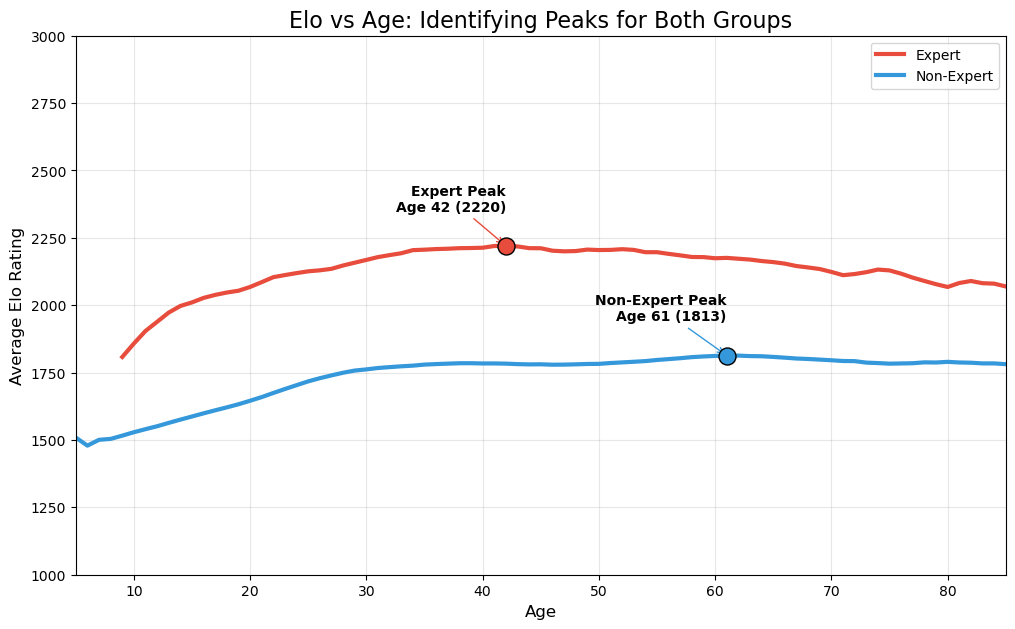

In [10]:
# 1. Preparation
df['Age'] = 2026 - df['B-day']
df['Category'] = df['Tit'].apply(lambda x: 'Expert' if pd.notnull(x) and x != '' else 'Non-Expert')

# 2. Grouping
trend = df.groupby(['Category', 'Age'])['FEB26'].mean().reset_index()

plt.figure(figsize=(12, 7))
colors = {'Expert': '#e74c3c', 'Non-Expert': '#3498db'}

for cat in ['Expert', 'Non-Expert']:
    subset = trend[trend['Category'] == cat].sort_values('Age')
    
    # 3. Smoothing (Crucial for finding a clean peak)
    subset['Smoothed'] = subset['FEB26'].rolling(window=5, center=True).mean().fillna(subset['FEB26'])
    
    # Plot the main line
    plt.plot(subset['Age'], subset['Smoothed'], label=cat, color=colors[cat], linewidth=3)
    
    # 4. Finding the Peak within a "Competitive Window" (Ages 15-65)
    # This ignores the 'noise' from very young or very old players
    peak_window = subset[(subset['Age'] >= 15) & (subset['Age'] <= 65)]
    
    if not peak_window.empty:
        peak_idx = peak_window['Smoothed'].idxmax()
        peak_age = peak_window.loc[peak_idx, 'Age']
        peak_elo = peak_window.loc[peak_idx, 'Smoothed']
        
        # 5. Adding the Markers
        plt.scatter(peak_age, peak_elo, color=colors[cat], s=150, edgecolors='black', zorder=5)
        plt.annotate(f'{cat} Peak\nAge {int(peak_age)} ({int(peak_elo)})', 
                     xy=(peak_age, peak_elo), 
                     xytext=(0, 25), 
                     textcoords='offset points',
                     ha='right', fontsize=10, fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color=colors[cat]))

# Final touches
plt.title('Elo vs Age: Identifying Peaks for Both Groups', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Average Elo Rating', fontsize=12)
plt.ylim(1000,3000)
plt.xlim(5, 85)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()